# Verification: adaptive MAPK resistance (Fröhlich et al., 2023)

This notebook verifies the condition-specific MARM2.0 model for the **1 µM vemurafenib + 100 ng/mL EGF** trajectory in Fig. 2A of Fröhlich et al. (2023), *Molecular Systems Biology* 19:e10988.

**Model-specification verification.** BioNetGen expands the 61 energy-aware rules to 1,612 species and 17,516 unidirectional reactions. We independently parse that generated network, assemble `dy/dt = S r(y)`, implement the four state-dependent feedback rates, and integrate it with SciPy/BDF.

**Source-model verification.** The committed source-model curve was regenerated from the authors' supplementary PySB MARM2.0 model (`RTKERK__pRAF.py`) with the best-ranked calibrated parameter set (row 0), after 24 h adaptation to vemurafenib. This tabular source-model output is preferable to digitizing the plotted ensemble line. The curated BNGL trajectory must match it to numerical precision.

The supplement's Fig. 2A experimental measurements are also overlaid and summarized, but are not used as a numerical equivalence tolerance because they are biological observations rather than a second implementation of the equations. Units are hours and the paper's pERK immunofluorescence scale.

In [1]:
import math
import os
import shutil
import subprocess
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.sparse import csc_matrix

STEM = "mapk_adaptive_resistance_frohlich2023"

def find_model_dir():
    for candidate in (Path.cwd(), Path.cwd() / "models" / STEM,
                      Path.cwd().parent / "models" / STEM):
        if (candidate / f"{STEM}.bngl").exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate the curated model directory")

MODEL_DIR = find_model_dir()
MODEL_FILE = MODEL_DIR / f"{STEM}.bngl"
REF_DIR = MODEL_DIR / "reference"
PNG_FILE = MODEL_DIR / "verify_frohlich2023.png"
print(f"Model directory: {MODEL_DIR}")

Model directory: /Users/wish/Code/BNGL-Models/models/mapk_adaptive_resistance_frohlich2023


## 1. Run the final BNGL model

The model starts from the authors' 24 h vemurafenib-adapted state and executes the active 2 h EGF pulse. A temporary directory prevents the verification run from modifying committed reference files.

In [2]:
def find_bionetgen():
    found = shutil.which("bionetgen")
    if found:
        return found
    repo_candidate = MODEL_DIR.parents[1] / ".venv" / "bin" / "bionetgen"
    if repo_candidate.exists():
        return str(repo_candidate)
    raise FileNotFoundError("BioNetGen executable not found")

run_dir = Path(tempfile.mkdtemp(prefix="frohlich2023_"))
bng = find_bionetgen()
proc = subprocess.run([bng, "run", "-i", str(MODEL_FILE), "-o", str(run_dir)],
                      text=True, capture_output=True)
if proc.returncode:
    print(proc.stdout[-4000:])
    print(proc.stderr[-4000:])
    raise RuntimeError("BioNetGen run failed")
run_net = run_dir / f"{STEM}_ode.net"
run_gdat = run_dir / f"{STEM}_ode.gdat"
print("BioNetGen run completed")
print(next(line for line in proc.stdout.splitlines() if line.startswith("Total   :")))

BioNetGen run completed
Total   : 17516 reactions 1.11e+01 CPU s 6.37e-04 CPU s/rxn


## 2. Independent SciPy implementation of the generated network

The parser evaluates BioNetGen's constant expressions, builds the sparse stoichiometry and observable matrices, and evaluates mass-action rates. Fixed EGF and vemurafenib species are held constant. Three transcription functions depend on pERK and the EGFR internalization function depends on plasma-membrane pEGFR; these four nonlinear rates are implemented explicitly below.

In [3]:
def parse_net(path):
    env = {"ln": math.log, "log": math.log, "exp": math.exp, "sqrt": math.sqrt}
    params, y0, patterns, reactions, groups = {}, [], [], [], []
    block = None
    for raw in open(path):
        line = raw.strip()
        if not line or line.startswith("#"):
            continue
        if line.startswith("begin "):
            block = line.split()[1]
            continue
        if line.startswith("end "):
            block = None
            continue
        body = line.split("#", 1)[0].strip()
        fields = body.split()
        if block == "parameters":
            name = fields[1]
            expr = "".join(fields[2:]).replace("^", "**")
            params[name] = float(eval(expr, {"__builtins__": {}}, env | params))
        elif block == "species":
            patterns.append(fields[1])
            y0.append(float(eval("".join(fields[2:]), {"__builtins__": {}}, env | params)))
        elif block == "reactions":
            reactants = [int(x) - 1 for x in fields[1].split(",") if x != "0"]
            products = [int(x) - 1 for x in fields[2].split(",") if x != "0"]
            reactions.append((reactants, products, fields[3]))
        elif block == "groups":
            group = body.split(None, 2)
            members = [] if len(group) < 3 else [
                (int(token.split("*")[-1]) - 1,
                 float(token.split("*")[0]) if "*" in token else 1.0)
                for token in group[2].split(",") if token
            ]
            groups.append((group[1], members))

    n, m = len(y0), len(reactions)
    group_map = {
        name: (np.array([i for i, _ in members], dtype=int),
               np.array([w for _, w in members], dtype=float))
        for name, members in groups
    }
    dynamic_names = ["msynthesize_pERK_DUSP_ksyn", "catalyze_EGFR_kendo",
                     "msynthesize_pERK_EGFR_ksyn", "msynthesize_pERK_SPRY_ksyn"]
    rows, cols, values = [], [], []
    ra = np.full(m, -1, dtype=int)
    rb = np.full(m, -1, dtype=int)
    constants = np.empty(m)
    dynamic_kind = np.full(m, -1, dtype=int)
    for j, (reactants, products, expr) in enumerate(reactions):
        if reactants:
            ra[j] = reactants[0]
        if len(reactants) > 1:
            rb[j] = reactants[1]
        for species in reactants:
            rows.append(species); cols.append(j); values.append(-1.0)
        for species in products:
            rows.append(species); cols.append(j); values.append(1.0)
        for kind, name in enumerate(dynamic_names):
            if name in expr:
                dynamic_kind[j] = kind
                expr = expr.replace(name, "1")
        constants[j] = float(eval(expr, {"__builtins__": {}}, env | params))
    S = csc_matrix((values, (rows, cols)), shape=(n, m))
    fixed = np.array(["$" in pattern for pattern in patterns])
    return {"params": params, "y0": np.array(y0), "patterns": patterns,
            "reactions": reactions, "groups": group_map, "S": S,
            "ra": ra, "rb": rb, "constants": constants,
            "dynamic_kind": dynamic_kind, "fixed": fixed}

net = parse_net(run_net)
print(f"Parsed {len(net['y0'])} species and {len(net['reactions'])} reactions")

Parsed 1612 species and 17516 reactions


In [4]:
def group_value(net, name, y):
    indices, weights = net["groups"][name]
    return np.dot(weights, y[indices])

def dynamic_values(net, y):
    p = net["params"]
    perk = group_value(net, "modulation_synthesize_pERK_DUSP_ERK", y)
    return np.array([
        p["msynthesize_pERK_DUSP_kbase"] *
        (1 + perk * p["synthesize_pERK_DUSP_ERK_gexpslope"] /
         (perk + p["synthesize_pERK_DUSP_ERK_kM"])),
        p["catalyze_EGFR_endo_kcat"] /
        (group_value(net, "pEGFR_PM", y) + p["catalyze_EGFR_deg_kM"]),
        p["msynthesize_pERK_EGFR_kbase"] *
        (1 + perk * p["synthesize_pERK_EGFR_ERK_gexpslope"] /
         (perk + p["synthesize_pERK_EGFR_ERK_kM"])) * p["EGFR_crispr"],
        p["msynthesize_pERK_SPRY_kbase"] *
        (1 + perk * p["synthesize_pERK_SPRY_ERK_gexpslope"] /
         (perk + p["synthesize_pERK_SPRY_ERK_kM"]))
    ])

def make_rhs(net):
    ra, rb, S = net["ra"], net["rb"], net["S"]
    first = np.flatnonzero((ra >= 0) & (rb < 0))
    second = np.flatnonzero(rb >= 0)
    dynamic = np.flatnonzero(net["dynamic_kind"] >= 0)
    def rhs(_time, y):
        rates = net["constants"].copy()
        rates[dynamic] *= dynamic_values(net, y)[net["dynamic_kind"][dynamic]]
        rates[first] *= y[ra[first]]
        rates[second] *= y[ra[second]] * y[rb[second]]
        derivative = S @ rates
        derivative[net["fixed"]] = 0.0
        return derivative
    return rhs

def jacobian_sparsity(net):
    rows, cols = [], []
    extra = [net["groups"]["modulation_synthesize_pERK_DUSP_ERK"][0],
             net["groups"]["pEGFR_PM"][0],
             net["groups"]["modulation_synthesize_pERK_EGFR_ERK"][0],
             net["groups"]["modulation_synthesize_pERK_SPRY_ERK"][0]]
    for j, (reactants, products, _expr) in enumerate(net["reactions"]):
        dependencies = list(set(reactants))
        kind = net["dynamic_kind"][j]
        if kind >= 0:
            dependencies += list(extra[kind])
        for affected in set(reactants + products):
            if not net["fixed"][affected]:
                for dependency in dependencies:
                    rows.append(affected); cols.append(dependency)
    return csc_matrix((np.ones(len(rows), dtype=bool), (rows, cols)),
                      shape=(len(net["y0"]), len(net["y0"])))

def load_gdat(path):
    header = open(path).readline().lstrip("#").split()
    return header, np.atleast_2d(np.loadtxt(path))

header, bng_data = load_gdat(run_gdat)
times = bng_data[:, 0]
solution = solve_ivp(make_rhs(net), (times[0], times[-1]), net["y0"],
                     method="BDF", t_eval=times, rtol=2e-7, atol=2e-10,
                     jac_sparsity=jacobian_sparsity(net))
assert solution.success, solution.message

perk_i, perk_w = net["groups"]["pERK"]
terk_i, terk_w = net["groups"]["tERK"]
perk_fraction = (perk_w @ solution.y[perk_i]) / (terk_w @ solution.y[terk_i])
p = net["params"]
scipy_perk_if = perk_fraction * p["pERK_IF_scale"] + p["pERK_IF_offset"]
bng_perk_if = bng_data[:, header.index("pERK_IF_obs")]
scaled_error = np.abs(scipy_perk_if - bng_perk_if) / np.maximum(np.abs(bng_perk_if), 1.0)
print(f"SciPy vs BNG maximum scaled trajectory error: {scaled_error.max():.3e}")
assert scaled_error.max() < 2e-5

SciPy vs BNG maximum scaled trajectory error: 1.210e-06


## 3. Quantitative source-model and measurement comparisons

The authors' source-model output uses the same best-ranked parameter set and condition as the curated model. The tolerance is `1e-10` because both trajectories are direct tabular simulations, not pixel digitizations. The experimental RMSE is descriptive: Fig. 2A's plotted model line summarizes an ensemble of 50 calibrated parameter sets, while this curated executable is the best-ranked single set.

In [5]:
source = pd.read_csv(REF_DIR / "frohlich2023_fig2a_vemurafenib1um_source_model.csv")
measurements = pd.read_csv(REF_DIR / "frohlich2023_fig2a_vemurafenib1um_egf100ngml_measurements.csv")
source_interp = np.interp(times, source["time_h"], source["pERK_IF_source_model"])
source_error = np.abs(bng_perk_if - source_interp)
print(f"Curated BNG vs authors' source model maximum absolute error: {source_error.max():.3e}")
assert source_error.max() < 1e-10

measured_2h = measurements[measurements["time_h"] <= 2.0]
model_at_measurements = np.interp(measured_2h["time_h"], times, bng_perk_if)
rmse = np.sqrt(np.mean((model_at_measurements - measured_2h["pERK_IF_mean"])**2))
peak_index = np.argmax(bng_perk_if)
print(f"Model peak: {bng_perk_if[peak_index]:.4f} at {times[peak_index]:.3f} h")
print(f"RMSE versus Fig. 2A measurements through 2 h: {rmse:.4f} IF units")

Curated BNG vs authors' source model maximum absolute error: 0.000e+00
Model peak: 1.8135 at 0.100 h
RMSE versus Fig. 2A measurements through 2 h: 0.1984 IF units


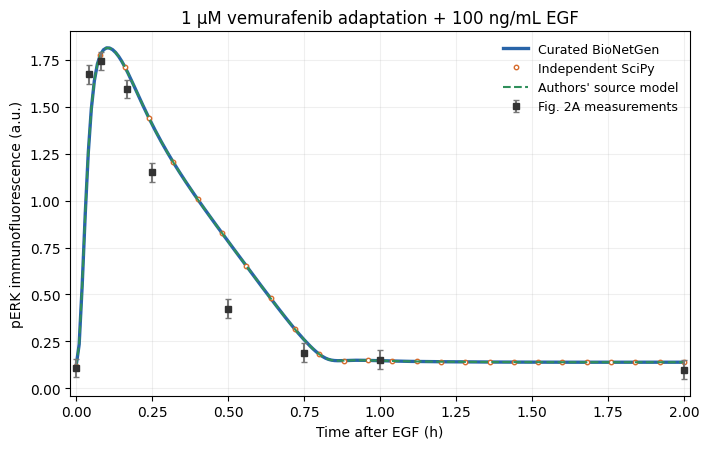

Saved verify_frohlich2023.png


In [6]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.plot(times, bng_perk_if, lw=2.4, color="#2864a8", label="Curated BioNetGen")
ax.plot(times, scipy_perk_if, "o", ms=3.2, mfc="white", mec="#d66b2c",
        markevery=8, label="Independent SciPy")
ax.plot(source["time_h"], source["pERK_IF_source_model"], "--", lw=1.5,
        color="#2f8f5b", label="Authors' source model")
ax.errorbar(measurements["time_h"], measurements["pERK_IF_mean"],
            yerr=measurements["pERK_IF_std"], fmt="s", ms=4.2,
            color="#333333", ecolor="#777777", capsize=2,
            label="Fig. 2A measurements")
ax.set(xlim=(-0.02, 2.02), xlabel="Time after EGF (h)",
       ylabel="pERK immunofluorescence (a.u.)",
       title="1 µM vemurafenib adaptation + 100 ng/mL EGF")
ax.grid(alpha=0.2)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(PNG_FILE, dpi=180)
plt.show()
print(f"Saved {PNG_FILE.name}")